In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
import scipy.stats as stats

c:\Users\admin\miniforge3\envs\Brain\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
GRAND_DIR = '../stimuli/Grand_et_al'
RATINGS_PATH = '../stimuli/moralgrammar68_human_ratings.json'
ITEMS_PATH = '../stimuli/MoralGrammar68.csv'
DILLION_PATH = '../stimuli/Dillion_et_al_2023.csv'

MODEL_ORDER = [
    'Qwen2.5-7B-Instruct',
    # 'Qwen2.5-14B-Instruct',
    # 'Qwen2.5-32b-instruct',
    # 'Qwen2.5-72b-instruct',

    'gemma-2-9b-it',
    # 'gemma-2-27b-it',

    'Mistral-Small-24B-Instruct-2501',

    'qwen3-8b',
    'qwen3-14b',
    'qwen3-32b',
    # 'Qwen3-235B-A22B',
    
    'gemma-3-4b-it',
    'gemma-3-12b-it',
    'gemma-3-27b-it',
    
]

MODEL_DISPLAY_NAMES = {
    'Qwen2.5-7B-Instruct':             'Qwen 2.5 7B',
    'Qwen2.5-14B-Instruct':            'Qwen 2.5 14B',
    'Qwen2.5-32b-instruct':            'Qwen 2.5 32B',
    'Qwen2.5-72b-instruct':            'Qwen 2.5 72B',
    'qwen3-8b':                        'Qwen 3 8B',
    'qwen3-14b':                       'Qwen 3 14B',
    'qwen3-32b':                       'Qwen 3 32B',
    'Qwen3-235B-A22B':                 'Qwen 3 235B',
    'gemma-2-9b-it':                   'Gemma 2 9B',
    'gemma-2-27b-it':                  'Gemma 2 27B',
    'gemma-3-4b-it':                   'Gemma 3 4B',
    'gemma-3-12b-it':                  'Gemma 3 12B',
    'gemma-3-27b-it':                  'Gemma 3 27B',
    'Mistral-Small-24B-Instruct-2501': 'Mistral Small 24B',
}

In [3]:
def load_projs(path):
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return None
    try:
        return pd.read_csv(path, index_col=0)
    except pd.errors.EmptyDataError:
        return None


def critical_r(n, alpha_two_tailed):
    if n is None or n < 3:
        return np.nan
    t_crit = stats.t.ppf(1 - alpha_two_tailed / 2, df=n - 2)
    return t_crit / np.sqrt(t_crit ** 2 + n - 2)


def select_models(required_files=(), data_dir='./data'):
    available = {d.lower(): d for d in os.listdir(data_dir)
                 if os.path.isdir(os.path.join(data_dir, d))}
    out = []
    for m in MODEL_ORDER:
        actual = available.get(m.lower())
        if actual is None:
            continue
        if all(os.path.exists(os.path.join(data_dir, actual, f))
               and os.path.getsize(os.path.join(data_dir, actual, f)) > 0
               for f in required_files):
            out.append(actual)
    return out


def _layer_scores(proj, reference):
    scores = {}
    if isinstance(reference, pd.DataFrame):
        for c in proj.columns:
            if c not in reference.columns:
                continue
            a, b = proj[c].values, reference[c].values
            if not (np.isfinite(a).all() and np.isfinite(b).all()):
                continue
            if a.std() == 0 or b.std() == 0:
                continue
            scores[c] = np.corrcoef(a, b)[0, 1]
    else:
        ref = np.asarray(reference)
        for c in proj.columns:
            v = proj[c].values
            if len(v) != len(ref):
                continue
            if not np.isfinite(v).all() or v.std() == 0:
                continue
            scores[c] = np.corrcoef(v, ref)[0, 1]
    return scores


def load_pair_projs(model_dir, stimset, concept):
    return load_projs(os.path.join(model_dir, f'{stimset}_{concept}_projections.csv'))


def has_pair_projs(model_dir, stimset, concept):
    path = os.path.join(model_dir, f'{stimset}_{concept}_projections.csv')
    return os.path.exists(path) and os.path.getsize(path) > 0


def pick_best_layer(model_dir, stimset, ref_concept=None, ref_array=None, *,
                     source='morality', apply_coherence_filter=False, alpha=0.05):
    proj = load_pair_projs(model_dir, stimset, source)
    if proj is None:
        return None
    if ref_concept is not None:
        ref = load_pair_projs(model_dir, stimset, ref_concept)
        if ref is None:
            return None
    else:
        ref = ref_array
    scores = _layer_scores(proj, ref)
    scores = {k: v for k, v in scores.items() if v > 0}

    if apply_coherence_filter:
        pairs = None
        if stimset == 'mg68':
            mg_m = load_pair_projs(model_dir, 'mg68', 'morality')
            mg_g = load_pair_projs(model_dir, 'mg68', 'grammar')
            if mg_m is not None and mg_g is not None:
                mg_ratings = pd.read_csv(ITEMS_PATH).merge(
                    pd.read_json(RATINGS_PATH, lines=True), on='item')
                pairs = [(mg_m, mg_ratings['morality_rating'].values),
                         (mg_g, mg_ratings['syntax_rating'].values)]
        elif stimset == 'me68':
            me_e = load_pair_projs(model_dir, 'me68', 'economic')
            if me_e is not None:
                me_meta = pd.read_csv('../stimuli/MoralEconomic68.csv')
                log_price = np.log(me_meta['price'].astype(float).values)
                pairs = [(me_e, log_price)]
        else:
            raise ValueError(f"unknown stimset: {stimset!r}")

        if pairs is not None:
            layer_cols = list(pairs[0][0].columns)
            n_tests = len(layer_cols) * len(pairs)
            alpha_bonf = alpha / max(n_tests, 1)

            valid = set()
            for col in layer_cols:
                ok = True
                for proj_df, rating in pairs:
                    if col not in proj_df.columns:
                        ok = False; break
                    v = proj_df[col].values
                    mask = np.isfinite(v) & np.isfinite(rating)
                    if mask.sum() < 3:
                        ok = False; break
                    r, p = stats.pearsonr(v[mask], rating[mask])
                    if not (r > 0 and p < alpha_bonf):
                        ok = False; break
                if ok:
                    valid.add(col)

            filtered = {k: v for k, v in scores.items() if k in valid}
            if filtered:
                scores = filtered
            else:
                print(f"  [{os.path.basename(model_dir)}|{stimset}] no layer passed the "
                      f"coherence filter (alpha_bonf={alpha_bonf:.2e}); "
                      f"falling back to unfiltered max")

    return max(scores, key=scores.get) if scores else None

# Figure 2

  [Qwen2.5-7B-Instruct|me68] no layer passed the coherence filter (alpha_bonf=1.79e-03); falling back to unfiltered max
  [mistral-small-24b-instruct-2501|me68] no layer passed the coherence filter (alpha_bonf=1.28e-03); falling back to unfiltered max
  [qwen3-8b|me68] no layer passed the coherence filter (alpha_bonf=1.39e-03); falling back to unfiltered max
  [qwen3-14b|me68] no layer passed the coherence filter (alpha_bonf=1.25e-03); falling back to unfiltered max
  [qwen3-32b|me68] no layer passed the coherence filter (alpha_bonf=7.81e-04); falling back to unfiltered max
  [gemma-3-4b-it|me68] no layer passed the coherence filter (alpha_bonf=1.47e-03); falling back to unfiltered max


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


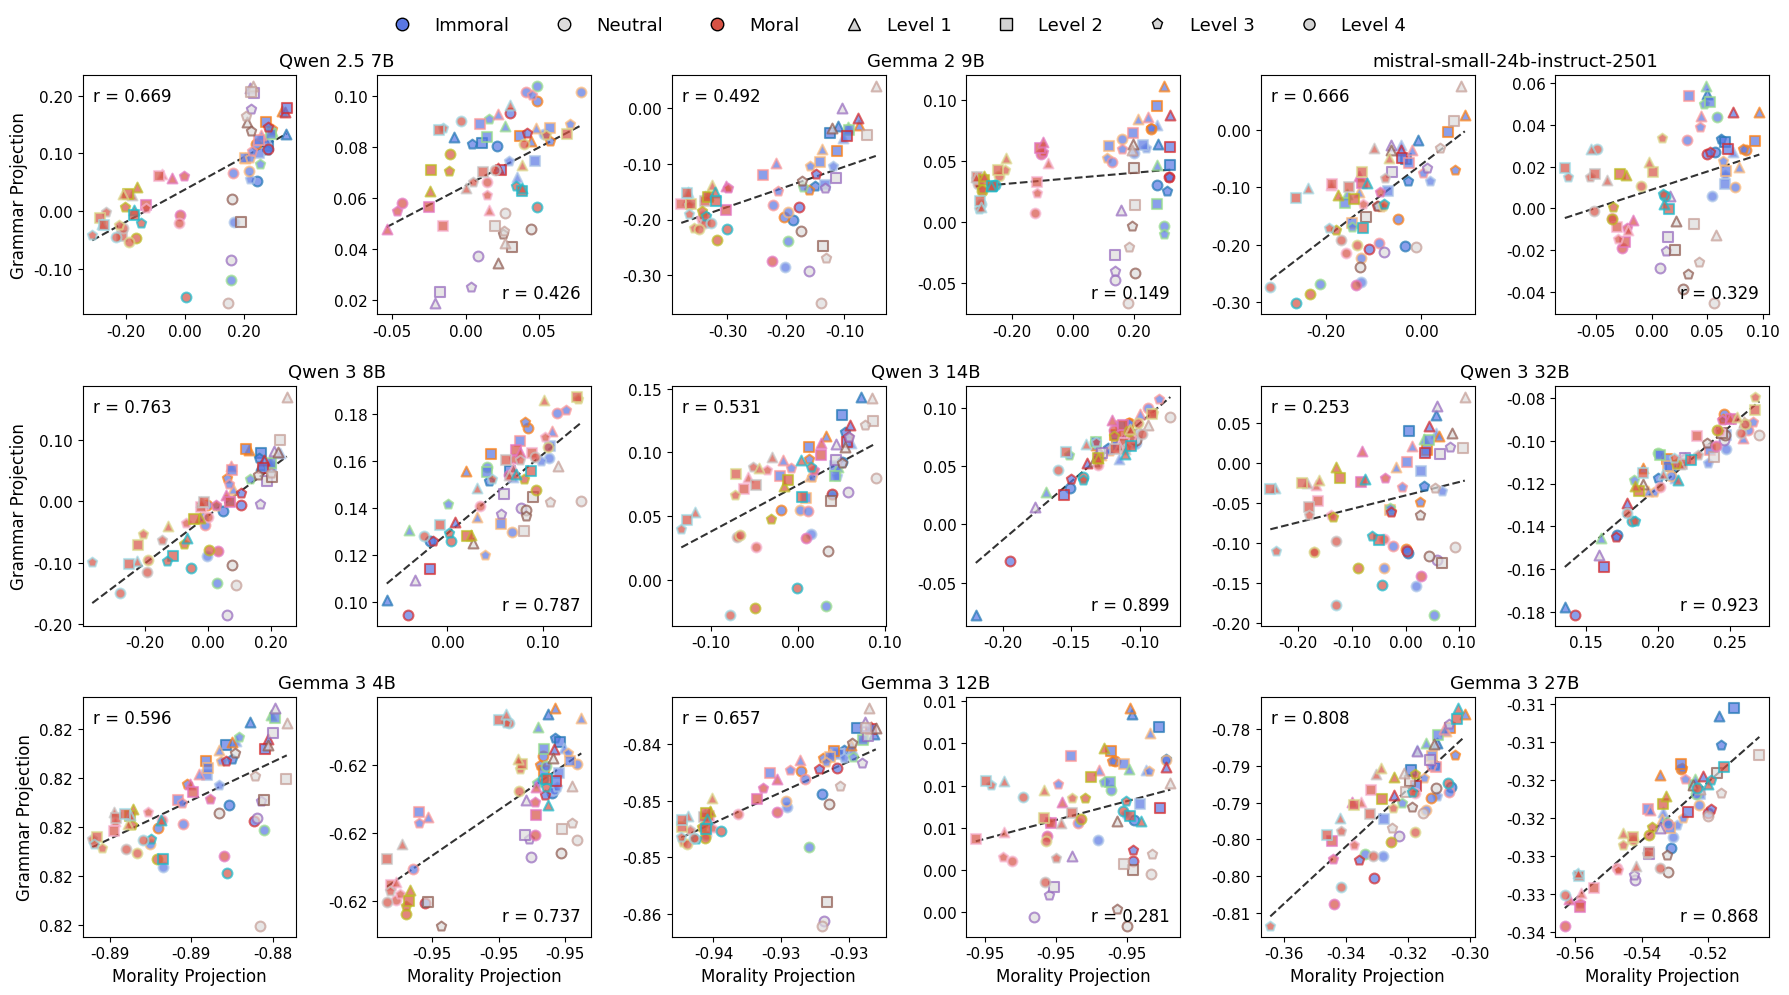

In [4]:
def plot_figure_2(data_dir='./data'):
    from matplotlib.lines import Line2D

    concepts = ('grammar', 'economic')
    ylabels = {'grammar': 'Grammar Projection', 'economic': 'Economic Projection'}
    stimsets = {'grammar': 'mg68', 'economic': 'me68'}
    items_paths = {'grammar': ITEMS_PATH, 'economic': '../stimuli/MoralEconomic68.csv'}
    items_by_concept = {c: pd.read_csv(p) for c, p in items_paths.items()}
    tier_keys = {'grammar': 'syntax_level', 'economic': 'economic_level'}

    markers = ['^', 's', 'p', 'o']
    morality_colors = [plt.cm.coolwarm(0.1), plt.cm.coolwarm(0.5), plt.cm.coolwarm(0.9)]
    morality_labels = ['Immoral', 'Neutral', 'Moral']
    edge_colormap = plt.cm.tab20

    required = ([f'{stimsets[c]}_{c}_projections.csv' for c in concepts] +
                [f'{stimsets[c]}_morality_projections.csv' for c in concepts])
    models = select_models(required, data_dir=data_dir)[:9]
    if not models:
        print('No models with morality+grammar+economic scenario projections.')
        return

    fig, axes = plt.subplots(3, 6, figsize=(18, 10))

    for m_idx, m in enumerate(models):
        row = m_idx // 3
        col_base = (m_idx % 3) * 2

        for c_idx, concept in enumerate(concepts):
            ax = axes[row, col_base + c_idx]
            stimset = stimsets[concept]
            best_layer = pick_best_layer(os.path.join(data_dir, m), stimset,
                                         ref_concept=concept, apply_coherence_filter=True)
            if best_layer is None:
                ax.set_visible(False)
                continue

            moral_proj = load_pair_projs(os.path.join(data_dir, m), stimset, 'morality')
            other_proj = load_pair_projs(os.path.join(data_dir, m), stimset, concept)
            items = items_by_concept[concept].copy()

            x = moral_proj[best_layer].values
            y = other_proj[best_layer].values

            scenario_ids = (items['id'].values if 'id' in items.columns
                            else (np.arange(len(items)) // 4) + 1)
            unique_ids = sorted(set(scenario_ids))
            n_scen = len(unique_ids)
            id_to_idx = {sid: i for i, sid in enumerate(unique_ids)}
            edge_colors_list = [edge_colormap(i / max(1, n_scen - 1)) for i in range(n_scen)]

            morality_levels = items['morality_level'].astype(int).values
            tier_levels = items[tier_keys[concept]].astype(int).values

            for i in range(len(items)):
                ax.scatter(x[i], y[i],
                           c=[morality_colors[morality_levels[i] - 1]],
                           marker=markers[tier_levels[i] - 1],
                           s=50, alpha=0.7,
                           edgecolors=[edge_colors_list[id_to_idx[scenario_ids[i]]]],
                           linewidths=1.5)

            r_value = np.corrcoef(x, y)[0, 1]
            slope, intercept, _, _, _ = stats.linregress(x, y)
            x_line = np.array([x.min(), x.max()])
            ax.plot(x_line, slope * x_line + intercept, 'k--',
                    linewidth=1.5, alpha=0.8, zorder=0)

            if concept == 'grammar':
                ax.text(0.05, 0.95, f'r = {r_value:.3f}', transform=ax.transAxes,
                        fontsize=12, verticalalignment='top')
            else:
                ax.text(0.95, 0.05, f'r = {r_value:.3f}', transform=ax.transAxes,
                        fontsize=12, verticalalignment='bottom', horizontalalignment='right')

            if row == 2:
                ax.set_xlabel('Morality Projection', fontsize=12)
            if col_base + c_idx == 0:
                ax.set_ylabel(ylabels[concept], fontsize=12)
            ax.tick_params(axis='both', which='major', labelsize=11)
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
            ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.subplots_adjust(hspace=0.30)
    for m_idx, m in enumerate(models):
        row = m_idx // 3
        col_base = (m_idx % 3) * 2
        left_ax, right_ax = axes[row, col_base], axes[row, col_base + 1]
        if not (left_ax.get_visible() and right_ax.get_visible()):
            continue
        pos_l, pos_r = left_ax.get_position(), right_ax.get_position()
        fig.text((pos_l.x0 + pos_r.x1) / 2, max(pos_l.y1, pos_r.y1) + 0.005,
                 MODEL_DISPLAY_NAMES.get(m, m),
                 ha='center', va='bottom', fontsize=13)

    # ── Top horizontal legend (matches exp3 Figure S2): morality-level fills
    #    + tier-level marker shapes. No frame. ──
    legend_handles = (
        [Line2D([0], [0], marker='o', color='w',
                markerfacecolor=morality_colors[k],
                markeredgecolor='black', markersize=9, label=lab)
         for k, lab in enumerate(morality_labels)]
        + [Line2D([0], [0], marker=mk, color='w',
                  markerfacecolor='lightgray',
                  markeredgecolor='black', markersize=8, label=f'Level {k + 1}')
           for k, mk in enumerate(markers)]
    )
    fig.legend(handles=legend_handles, loc='upper center',
               bbox_to_anchor=(0.5, 1.0), ncol=len(legend_handles),
               fontsize=13, frameon=False)

    os.makedirs('./figures', exist_ok=True)
    plt.savefig('./figures/figure_2_scatter_morality_grammar_economic.eps',
                format='eps', bbox_inches='tight')
    plt.show()

plot_figure_2()

# Figure S5

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


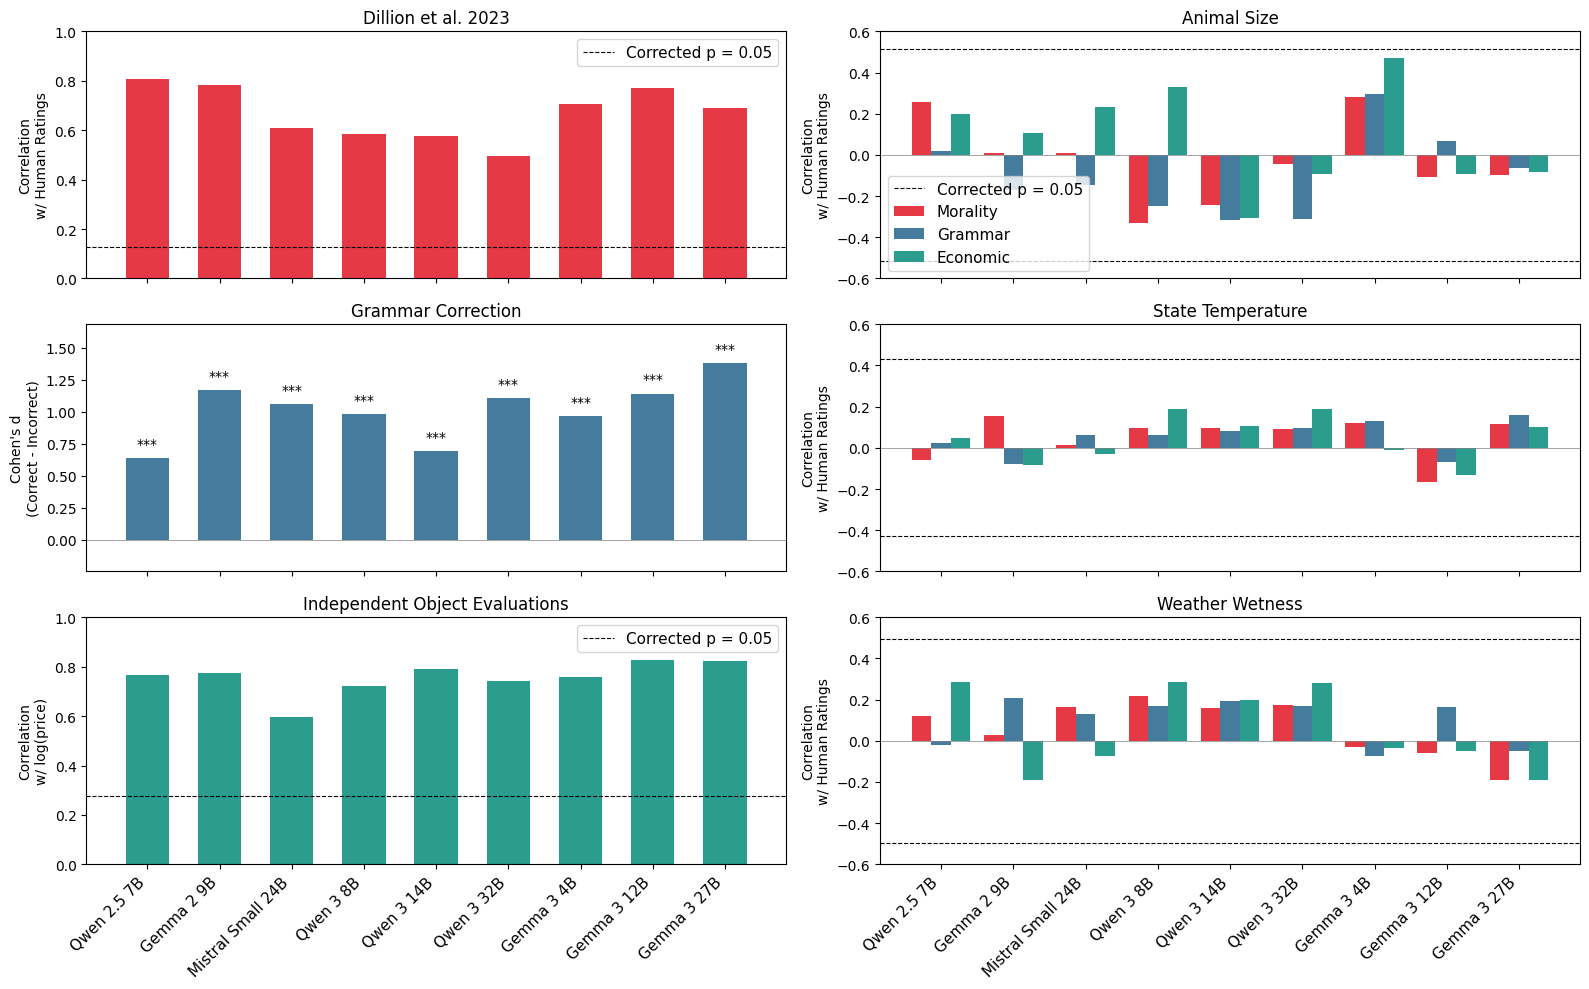

In [7]:
# ---- Edit me: panel titles & colors ----------------------------------------
S5_PANEL_TITLES = {
    'dillion':                    'Dillion et al. 2023',
    'grammar_correction':         "Grammar Correction",
    'economic':                   'Independent Object Evaluations',
    'grand_animals_size':         'Animal Size',
    'grand_states_temperature':   'State Temperature',
    'grand_weather_wetness':      'Weather Wetness',
}

S5_CONCEPT_COLORS = {
    'Morality': '#E63946',
    'Grammar':  '#457B9D',
    'Economic': '#2A9D8F',
}

S5_YLABELS = {
    'dillion':                    'Correlation\nw/ Human Ratings',
    'grammar_correction':         "Cohen's d\n(Correct - Incorrect)",
    'economic':                   'Correlation\nw/ log(price)',
    'grand_animals_size':         'Correlation\nw/ Human Ratings',
    'grand_states_temperature':   'Correlation\nw/ Human Ratings',
    'grand_weather_wetness':      'Correlation\nw/ Human Ratings',
}
# ----------------------------------------------------------------------------


def plot_figure_s5(data_dir='./data', alpha=0.05):
    concepts = ['Morality', 'Grammar', 'Economic']
    results = {}
    _mo_lower = {mm.lower(): mm for mm in MODEL_ORDER}
    def _canon(mm): return _mo_lower.get(mm.lower(), mm)

    # ---- Dillion ---------------------------------------------------------
    dillion_ratings = pd.read_csv(DILLION_PATH)['Human rating'].values
    n_dillion = len(dillion_ratings)
    moral_ratings = (pd.read_csv(ITEMS_PATH)
                     .merge(pd.read_json(RATINGS_PATH, lines=True), on='item')
                     ['morality_rating'].values)

    for m in select_models(['dillion_morality_projections.csv'], data_dir=data_dir):
        projs = load_projs(os.path.join(data_dir, m, 'dillion_morality_projections.csv'))
        chosen = pick_best_layer(os.path.join(data_dir, m), 'mg68', ref_array=moral_ratings)
        if projs is None or chosen is None or chosen not in projs.columns:
            continue
        r, _ = stats.pearsonr(projs[chosen].values, dillion_ratings)
        results.setdefault(_canon(m), {})['dillion_r'] = r

    # ---- Grammar correction ----------------------------------------------
    grammar_n = None
    for m in select_models(['grammar_correction_correct_projections.csv',
                            'grammar_correction_incorrect_projections.csv'],
                           data_dir=data_dir):
        c_df = load_projs(os.path.join(data_dir, m, 'grammar_correction_correct_projections.csv'))
        i_df = load_projs(os.path.join(data_dir, m, 'grammar_correction_incorrect_projections.csv'))
        if c_df is None or i_df is None:
            continue
        cols = [col for col in c_df.columns if col in i_df.columns]
        if not cols:
            continue
        c_arr, i_arr = c_df[cols].values, i_df[cols].values

        n_layers = c_arr.shape[1]
        d_layers = np.full(n_layers, np.nan)
        for layer in range(n_layers):
            cv, iv = c_arr[:, layer], i_arr[:, layer]
            if not (np.any(cv) or np.any(iv)):
                continue
            sd = np.sqrt(0.5 * (cv.var(ddof=1) + iv.var(ddof=1)))
            if sd == 0 or not np.isfinite(sd):
                continue
            d_layers[layer] = (cv.mean() - iv.mean()) / sd
        if np.all(np.isnan(d_layers)):
            continue
        best = int(np.nanargmax(np.abs(d_layers)))
        cv_best, iv_best = c_arr[:, best], i_arr[:, best]
        mask = np.isfinite(cv_best) & np.isfinite(iv_best)
        if mask.sum() < 2:
            continue
        cv_best, iv_best = cv_best[mask], iv_best[mask]
        _, p_paired = stats.ttest_rel(cv_best, iv_best)
        results.setdefault(_canon(m), {}).update({
            'grammar_d':     d_layers[best],
            'grammar_p':     p_paired,
            'grammar_layer': best,
        })
        grammar_n = cv_best.size

    # ---- Economic projection vs sign(value)*log(|value|) -----------------
    test_value = pd.read_csv('../stimuli/test_value.csv')
    test_values_arr = test_value['value'].astype(float).values
    log_test_values = np.sign(test_values_arr) * np.log(np.abs(test_values_arr))

    available_econ = {d.lower(): d for d in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, d))}

    for m in MODEL_ORDER:
        actual = available_econ.get(m.lower())
        if actual is None:
            continue
        proj_path = None
        for fname in ('test_value_economic_projections.csv',
                      'economic_on_economic_projections.csv'):
            p = os.path.join(data_dir, actual, fname)
            if os.path.exists(p) and os.path.getsize(p) > 0:
                proj_path = p
                break
        if proj_path is None:
            continue
        df = pd.read_csv(proj_path, index_col=0)
        if 'value' in df.columns:
            vals = df['value'].astype(float).values
            log_v = np.sign(vals) * np.log(np.abs(vals))
            projs_df = df.drop(columns=['value'])
        else:
            n = min(len(df), len(log_test_values))
            log_v = log_test_values[:n]
            projs_df = df.iloc[:n]

        best_r = None
        for col in projs_df.columns:
            v = projs_df[col].values
            mask = np.isfinite(v) & np.isfinite(log_v)
            if mask.sum() < 3 or v[mask].std() == 0:
                continue
            r, _ = stats.pearsonr(v[mask], log_v[mask])
            if not np.isfinite(r):
                continue
            if best_r is None or r > best_r:
                best_r = r
        if best_r is None:
            continue
        results.setdefault(_canon(m), {})['econ_r'] = best_r
    n_econ = len(test_values_arr)

    # ---- Grand controls --------------------------------------------------
    candidate_grand = select_models(data_dir=data_dir)
    stimuli = set()
    for m in candidate_grand:
        for f in os.listdir(os.path.join(data_dir, m)):
            if f.startswith('grand_') and f.endswith('_morality_projections.csv'):
                if os.path.getsize(os.path.join(data_dir, m, f)) > 0:
                    stimuli.add(f[len('grand_'):-len('_morality_projections.csv')])
    stimuli = sorted(s for s in stimuli if s != 'names_age')

    for m in candidate_grand:
        chosen = pick_best_layer(os.path.join(data_dir, m), 'me68', ref_concept='economic')
        if chosen is None:
            continue
        if any(load_projs(os.path.join(data_dir, m, f'grand_{s}_{c}_projections.csv')) is not None
               for s in stimuli for c in concepts):
            results.setdefault(_canon(m), {})['grand_layer'] = chosen

    # ---- Unified model list (intersection across panels) -----------------
    required_keys = ('dillion_r', 'grammar_d', 'econ_r', 'grand_layer')
    panel_models = [m for m in MODEL_ORDER
                    if all(k in results.get(m, {}) for k in required_keys)]
    n_panel = max(len(panel_models), 1)
    alpha_dillion = alpha / n_panel
    alpha_econ    = alpha / n_panel
    alpha_grand   = alpha / (n_panel * len(concepts))

    # ---- Layout (3 rows x 2 cols, shared x-axis) ------------------------
    fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
    ax_dillion, ax_grammar, ax_econ = axes[:, 0]
    ax_grand = list(axes[:, 1])
    x = np.arange(len(panel_models))
    xtick_labels = [MODEL_DISPLAY_NAMES.get(m, m) for m in panel_models]

    # ---- Render: Dillion -------------------------------------------------
    ax_dillion.bar(x, [results[m]['dillion_r'] for m in panel_models],
                   0.6, color=S5_CONCEPT_COLORS['Morality'])
    for sgn in (-1, 1):
        ax_dillion.axhline(sgn * critical_r(n_dillion, alpha_dillion),
                           color='black', linestyle='--', linewidth=0.8,
                           label=f'Corrected p = {alpha}' if sgn == 1 else None)
    ax_dillion.axhline(0, color='gray', linestyle='-', linewidth=0.5)
    ax_dillion.set_ylabel(S5_YLABELS['dillion'])
    ax_dillion.set_title(S5_PANEL_TITLES['dillion'])
    ax_dillion.set_ylim([0, 1])
    ax_dillion.legend(fontsize=11, loc='upper right')

    # ---- Render: Grammar correction (Cohen's d) --------------------------
    grammar_ds = np.array([results[m]['grammar_d'] for m in panel_models])
    grammar_ps = np.array([results[m]['grammar_p'] for m in panel_models])
    ax_grammar.bar(x, grammar_ds, 0.6, color=S5_CONCEPT_COLORS['Grammar'])
    ax_grammar.axhline(0, color='gray', linestyle='-', linewidth=0.5)
    ax_grammar.set_ylabel(S5_YLABELS['grammar_correction'])
    title = S5_PANEL_TITLES['grammar_correction']
    if grammar_n is not None:
        title = f"{title}"
    ax_grammar.set_title(title)

    ymax = max(np.nanmax(grammar_ds), 0.0)
    ymin = min(np.nanmin(grammar_ds), 0.0)
    span = max(ymax - ymin, 1e-6)
    offset = span * 0.04
    for i, (d, p) in enumerate(zip(grammar_ds, grammar_ps)):
        if not np.isfinite(p):
            continue
        if   p < 0.001 / n_panel: stars = '***'
        elif p < 0.01  / n_panel: stars = '**'
        elif p < 0.05  / n_panel: stars = '*'
        else:                     stars = 'n.s.'
        ax_grammar.text(i, (d + offset) if d >= 0 else (d - offset),
                        stars, ha='center',
                        va='bottom' if d >= 0 else 'top', fontsize=10)
    ax_grammar.set_ylim(ymin - span * 0.18, ymax + span * 0.22)

    # ---- Render: Economic correlation vs sign(value)*log(|value|) -------
    ax_econ.bar(x, [results[m]['econ_r'] for m in panel_models],
                0.6, color=S5_CONCEPT_COLORS['Economic'])
    for sgn in (-1, 1):
        ax_econ.axhline(sgn * critical_r(n_econ, alpha_econ),
                        color='black', linestyle='--', linewidth=0.8,
                        label=f'Corrected p = {alpha}' if sgn == 1 else None)
    ax_econ.axhline(0, color='gray', linestyle='-', linewidth=0.5)
    ax_econ.set_ylabel(S5_YLABELS['economic'])
    ax_econ.set_title(S5_PANEL_TITLES['economic'])
    ax_econ.set_ylim([0, 1])
    ax_econ.legend(fontsize=11, loc='upper right')

    # ---- Render: Grand controls -----------------------------------------
    width = 0.27
    for ind, stim in enumerate(stimuli[:3]):
        ax = ax_grand[ind]
        df = pd.read_csv(f'{GRAND_DIR}/grand_{stim}.csv')
        ratings = df.iloc[:, 1:].mean(axis=1).values
        n_items = len(ratings)

        for i_concept, concept in enumerate(concepts):
            corrs = []
            for m in panel_models:
                projs = load_projs(os.path.join(data_dir, m,
                                                f'grand_{stim}_{concept}_projections.csv'))
                col = results[m]['grand_layer']
                if projs is None or col not in projs.columns:
                    corrs.append(np.nan)
                    continue
                r, _ = stats.pearsonr(projs[col].values, ratings)
                corrs.append(r)
            ax.bar(x + (i_concept - 1) * width, corrs, width, label=concept,
                   color=S5_CONCEPT_COLORS[concept])

        for sgn in (-1, 1):
            ax.axhline(sgn * critical_r(n_items, alpha_grand),
                       color='black', linestyle='--', linewidth=0.8,
                       label=f'Corrected p = {alpha}' if sgn == 1 and ind == 0 else None)
        ax.axhline(0, color='gray', linestyle='-', linewidth=0.5)
        ax.set_ylabel(S5_YLABELS.get(f'grand_{stim}', 'Pearson r'))
        ax.set_title(S5_PANEL_TITLES.get(f'grand_{stim}', stim))
        ax.set_ylim([-0.6, 0.6])
        if ind == 0:
            ax.legend(fontsize=11, loc='lower left')

    # ---- Shared x-axis: labels on bottom row of each column -------------
    for ax in axes[-1, :]:
        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=11)

    plt.tight_layout()
    os.makedirs('./figures', exist_ok=True)
    plt.savefig('./figures/figure_s5_combined.eps', format='eps', bbox_inches='tight')
    plt.show()


plot_figure_s5()

# Grammar correction distributions

In [ ]:
_MO_LOWER = {m.lower(): m for m in MODEL_ORDER}


def _display_name(model_dir):
    canon = _MO_LOWER.get(model_dir.lower(), model_dir)
    return MODEL_DISPLAY_NAMES.get(canon, canon)


def _grid_axes(n, cols=3, panel_size=(5.2, 4.2)):
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(panel_size[0] * cols, panel_size[1] * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes[:n]


def best_separation_layer(correct_proj, incorrect_proj):
    n_layers = correct_proj.shape[1]
    dprimes = np.full(n_layers, np.nan)
    for layer in range(n_layers):
        c, i = correct_proj[:, layer], incorrect_proj[:, layer]
        sd = np.sqrt(0.5 * (c.var(ddof=1) + i.var(ddof=1)))
        if sd == 0 or not np.isfinite(sd):
            continue
        dprimes[layer] = abs(c.mean() - i.mean()) / sd
    if np.all(np.isnan(dprimes)):
        return None, dprimes
    return int(np.nanargmax(dprimes)), dprimes


def plot_grammar_histograms(data_dir='./data', cols=3, save=True):
    models = select_models(['grammar_correction_correct_projections.csv',
                            'grammar_correction_incorrect_projections.csv'],
                           data_dir=data_dir)
    if not models:
        print('no models with grammar-correction projections')
        return
    fig, axes = _grid_axes(len(models), cols=cols)

    for ax, model_dir in zip(axes, models):
        c_df = load_projs(os.path.join(data_dir, model_dir,
                                       'grammar_correction_correct_projections.csv'))
        i_df = load_projs(os.path.join(data_dir, model_dir,
                                       'grammar_correction_incorrect_projections.csv'))
        cols_shared = [c for c in c_df.columns if c in i_df.columns]
        c_arr, i_arr = c_df[cols_shared].values, i_df[cols_shared].values

        layer, dprimes = best_separation_layer(c_arr, i_arr)
        if layer is None:
            ax.set_visible(False)
            continue
        c_layer, i_layer = c_arr[:, layer], i_arr[:, layer]

        bins = np.histogram_bin_edges(np.concatenate([c_layer, i_layer]), bins=25)
        ax.hist(i_layer, bins=bins, alpha=0.55, label='Ungrammatical',    color='#D62828', density=True)
        ax.hist(c_layer, bins=bins, alpha=0.55, label='Standard English', color='#2E86AB', density=True)
        ax.axvline(i_layer.mean(), color='#D62828', linestyle='--', linewidth=1.5)
        ax.axvline(c_layer.mean(), color='#2E86AB', linestyle='--', linewidth=1.5)

        ax.set_title(f'{_display_name(model_dir)}\nlayer {cols_shared[layer]}  (d = {dprimes[layer]:.2f})')
        ax.set_xlabel('Grammar-vector projection')
        ax.set_ylabel('Density')
        ax.legend(loc='best', fontsize=9)

    fig.suptitle('Grammar-vector projection: Standard English vs ungrammatical',
                 y=1.005, fontsize=14)
    plt.tight_layout()
    if save:
        os.makedirs('./figures/grammar_correction', exist_ok=True)
        plt.savefig('./figures/grammar_correction/histograms.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_grammar_histograms()

# Economic projection vs item value

In [ ]:
ECON_FILENAMES = ('test_value_economic_projections.csv',
                  'economic_on_economic_projections.csv')


def resolve_test_value_path(model, data_dir='./data'):
    avail = {d.lower(): d for d in os.listdir(data_dir)
             if os.path.isdir(os.path.join(data_dir, d))}
    actual = avail.get(model.lower())
    if actual is None:
        return None
    for fname in ECON_FILENAMES:
        p = os.path.join(data_dir, actual, fname)
        if os.path.exists(p) and os.path.getsize(p) > 0:
            return p
    return None


def best_economic_layer(econ_proj, log_values):
    n_layers = econ_proj.shape[1]
    rs = np.full(n_layers, np.nan)
    for layer in range(n_layers):
        v = econ_proj[:, layer]
        mask = np.isfinite(v) & np.isfinite(log_values)
        if mask.sum() < 3 or v[mask].std() == 0:
            continue
        rs[layer] = np.corrcoef(v[mask], log_values[mask])[0, 1]
    if np.all(np.isnan(rs)):
        return None, rs
    masked = np.where(rs > 0, rs, -np.inf) if np.any(rs > 0) else rs
    return int(np.nanargmax(masked)), rs


def plot_economic_scatters(data_dir='./data', cols=3, save=True):
    fallback = pd.read_csv('../stimuli/test_value.csv')['value'].astype(float).values
    fallback_log = np.sign(fallback) * np.log(np.abs(fallback))

    entries = []
    for m in MODEL_ORDER:
        p = resolve_test_value_path(m, data_dir=data_dir)
        if p is not None:
            entries.append((m, p))
    if not entries:
        print('no models with test_value economic projections')
        return
    fig, axes = _grid_axes(len(entries), cols=cols)

    for ax, (model, path) in zip(axes, entries):
        df = pd.read_csv(path, index_col=0)
        if 'value' in df.columns:
            vals = df['value'].astype(float).values
            log_v = np.sign(vals) * np.log(np.abs(vals))
            proj = df.drop(columns=['value'])
        else:
            n = min(len(df), len(fallback_log))
            log_v = fallback_log[:n]
            proj = df.iloc[:n]

        layer, rs = best_economic_layer(proj.values, log_v)
        if layer is None:
            ax.set_visible(False)
            continue
        y = proj.values[:, layer]
        mask = np.isfinite(y) & np.isfinite(log_v)
        x, y = log_v[mask], y[mask]

        ax.scatter(x, y, alpha=0.65, s=42, edgecolors='black', linewidths=0.4, color='#2A9D8F')
        slope, intercept, r, p, _ = stats.linregress(x, y)
        x_line = np.array([x.min(), x.max()])
        ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.4)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.4)

        ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.2e}',
                transform=ax.transAxes, va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_title(f'{MODEL_DISPLAY_NAMES.get(model, model)}\n'
                     f'layer {proj.columns[layer]}  (r = {r:.2f})')
        ax.set_xlabel('sign(value) x log(|value|)  [USD]')
        ax.set_ylabel('Economic-vector projection')
        ax.grid(True, linestyle='--', alpha=0.3)

    fig.suptitle('Economic-vector projection vs item value', y=1.005, fontsize=14)
    plt.tight_layout()
    if save:
        os.makedirs('./figures/grammar_correction', exist_ok=True)
        plt.savefig('./figures/grammar_correction/economic_scatters.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_economic_scatters()

# Figure S6

In [ ]:
def plot_projections_by_morality_level(data_dir='./data'):
    panels = [
        ('mg68', 'grammar',  'morality_level', 'Level of Moral Harm', 'Grammaticality Projection'),
        ('mg68', 'grammar',  'syntax_level',   'Syntax Level',        'Grammaticality Projection'),
        ('me68', 'economic', 'morality_level', 'Level of Moral Harm', 'Economic Projection'),
        ('me68', 'economic', 'economic_level', 'Economic Level',      'Economic Projection'),
    ]
    items_paths = {'mg68': ITEMS_PATH, 'me68': '../stimuli/MoralEconomic68.csv'}
    items_by_stimset = {s: pd.read_csv(p) for s, p in items_paths.items()}

    required = list({f'{s}_{c}_projections.csv' for s, c, *_ in panels})
    models = select_models(required, data_dir=data_dir)[:9]
    if not models:
        print('No models with required projections.')
        return

    fig, axes = plt.subplots(9, 4, figsize=(12, 22))

    for m_idx, m in enumerate(models):
        for c_idx, (stimset, concept, split_col, xlabel, ylabel) in enumerate(panels):
            ax = axes[m_idx, c_idx]
            best_layer = pick_best_layer(os.path.join(data_dir, m), stimset,
                                         ref_concept=concept, apply_coherence_filter=True)
            if best_layer is None:
                ax.set_visible(False)
                continue
            projs = load_pair_projs(os.path.join(data_dir, m), stimset, concept)
            df = items_by_stimset[stimset].copy()
            df['y'] = projs[best_layer].values

            sns.stripplot(x=split_col, y='y', hue=split_col, data=df,
                          size=4, jitter=True, ax=ax, legend=False)
            means = df.groupby(split_col)['y'].mean()
            ses = df.groupby(split_col)['y'].sem()
            ax.errorbar(range(len(means)), means.values, yerr=ses.values, fmt='.',
                        color='black', elinewidth=1, capsize=4, markersize=6)

            ax.set_ylabel(ylabel if c_idx in (0, 2) else '')
            ax.set_xlabel(xlabel if m_idx == len(models) - 1 else '')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.25)

    for m_idx, m in enumerate(models):
        row_axes = axes[m_idx, :]
        if not all(ax.get_visible() for ax in row_axes):
            continue
        positions = [ax.get_position() for ax in row_axes]
        center_x = (positions[0].x0 + positions[-1].x1) / 2
        top_y = max(p.y1 for p in positions)
        fig.text(center_x, top_y + 0.003, MODEL_DISPLAY_NAMES.get(m, m),
                 ha='center', va='bottom', fontsize=13)
    os.makedirs('./figures', exist_ok=True)
    plt.savefig('./figures/figure_s6_projections_by_level.eps', format='eps')
    plt.show()

plot_projections_by_morality_level()

# Figure S7

In [ ]:
# -- Figure S7 -- Behavior ↔ Activation slopegraph by model family --
from matplotlib.lines import Line2D
from matplotlib import cm as _cm

EXP3_DATA_DIR = '../exp3/data'
EXP4_DATA_DIR = './data'
ECONOMIC_ITEMS_PATH = '../stimuli/MoralEconomic68.csv'

FAMILIES = ['Qwen2.5', 'Qwen3', 'Gemma-2', 'Gemma-3', 'Mistral']

MODEL_META = {
    'qwen2.5-7b-instruct':              (7,   'Qwen2.5'),
    'qwen2.5-14b-instruct':             (14,  'Qwen2.5'),
    'qwen2.5-32b-instruct':             (32,  'Qwen2.5'),
    'qwen2.5-72b-instruct':             (72,  'Qwen2.5'),

    'qwen3-8b':                         (8,   'Qwen3'),
    'qwen3-14b':                        (14,  'Qwen3'),
    'qwen3-32b':                        (32,  'Qwen3'),
    'qwen3-235b-a22b':                  (235, 'Qwen3'),

    'gemma-2-9b-it':                    (9,   'Gemma-2'),
    'gemma-2-27b-it':                   (27,  'Gemma-2'),

    'gemma-3-4b-it':                    (4,   'Gemma-3'),
    'gemma-3-12b-it':                   (12,  'Gemma-3'),
    'gemma-3-27b-it':                   (27,  'Gemma-3'),

    'mistral-small-24b-instruct-2501':  (24,  'Mistral'),
}


def _normalize(name):
    return name.lower().replace('qwen-2.5', 'qwen2.5')


_ORDER_NORM = {_normalize(m) for m in MODEL_ORDER}


def _exp3_corr_row(model_dir):
    grammar_csv  = os.path.join(EXP3_DATA_DIR, model_dir, 'moralgrammar68_ratings.csv')
    economic_csv = os.path.join(EXP3_DATA_DIR, model_dir, 'moraleconomic68_ratings.csv')
    r_mg = p_mg = r_me = p_me = np.nan
    if os.path.exists(grammar_csv):
        gr = pd.read_csv(ITEMS_PATH).merge(pd.read_csv(grammar_csv), on='item', how='left')
        gr = gr.dropna(subset=['morality_mean', 'grammar_mean'])
        if len(gr) >= 2:
            r_mg, p_mg = stats.pearsonr(gr['morality_mean'], gr['grammar_mean'])
    if os.path.exists(economic_csv):
        ec = pd.read_csv(ECONOMIC_ITEMS_PATH).merge(pd.read_csv(economic_csv), on='item', how='left')
        ec = ec.dropna(subset=['morality_mean', 'economic_mean'])
        if len(ec) >= 2:
            r_me, p_me = stats.pearsonr(ec['morality_mean'], ec['economic_mean'])
    return r_mg, p_mg, r_me, p_me


def _exp4_corr_row(model_dir):
    base = os.path.join(EXP4_DATA_DIR, model_dir)
    mg_moral = load_pair_projs(base, 'mg68', 'morality')
    grammar  = load_pair_projs(base, 'mg68', 'grammar')
    me_moral = load_pair_projs(base, 'me68', 'morality')
    economic = load_pair_projs(base, 'me68', 'economic')
    r_mg = p_mg = r_me = p_me = np.nan
    if mg_moral is not None and grammar is not None:
        best = pick_best_layer(base, 'mg68', ref_concept='grammar',
                               apply_coherence_filter=True)
        if best is not None:
            r_mg, p_mg = stats.pearsonr(mg_moral[best].values, grammar[best].values)
    if me_moral is not None and economic is not None:
        best = pick_best_layer(base, 'me68', ref_concept='economic',
                               apply_coherence_filter=True)
        if best is not None:
            r_me, p_me = stats.pearsonr(me_moral[best].values, economic[best].values)
    return r_mg, p_mg, r_me, p_me


def _build_df(data_dir, corr_fn):
    cols = ['model', 'family', 'params_b',
            'r_moral_grammar', 'p_moral_grammar',
            'r_moral_economic', 'p_moral_economic']
    if not os.path.exists(data_dir):
        return pd.DataFrame(columns=cols)
    rows = []
    for d in sorted(os.listdir(data_dir)):
        if not os.path.isdir(os.path.join(data_dir, d)):
            continue
        norm = _normalize(d)
        if norm not in _ORDER_NORM:
            continue
        meta = MODEL_META.get(norm)
        if meta is None:
            continue
        params_b, family = meta
        r_mg, p_mg, r_me, p_me = corr_fn(d)
        rows.append({
            'model': d, 'family': family, 'params_b': params_b,
            'r_moral_grammar': r_mg, 'p_moral_grammar': p_mg,
            'r_moral_economic': r_me, 'p_moral_economic': p_me,
        })
    return pd.DataFrame(rows, columns=cols)


df_exp3 = _build_df(EXP3_DATA_DIR, _exp3_corr_row)
df_exp4 = _build_df(EXP4_DATA_DIR, _exp4_corr_row)

df_exp3 = df_exp3.assign(_key=df_exp3['model'].map(_normalize))
df_exp4 = df_exp4.assign(_key=df_exp4['model'].map(_normalize))
merged = df_exp3.merge(
    df_exp4[['_key', 'r_moral_grammar', 'p_moral_grammar',
             'r_moral_economic', 'p_moral_economic']],
    on='_key', how='inner', suffixes=('_b', '_a'),
)

# ── Plot ──
KIND_LINESTYLE = {'mg': '-',  'me': '--'}
KIND_MARKER    = {'mg': 'o',  'me': 's'}
KIND_LABEL     = {'mg': 'Moral × Grammar', 'me': 'Moral × Economic'}
KIND_COLS = {
    'mg': ('r_moral_grammar_b',  'r_moral_grammar_a'),
    'me': ('r_moral_economic_b', 'r_moral_economic_a'),
}
MARKER_SIZE = 7
VIRIDIS = _cm.get_cmap('viridis')

fig, axes = plt.subplots(1, len(FAMILIES), figsize=(16, 4.4), sharey=True)
plt.rcParams.update({'font.size': 13})
X_BEH, X_ACT = 0.0, 1.0

for ax, family in zip(axes, FAMILIES):
    sub = merged[merged['family'] == family].sort_values('params_b').reset_index(drop=True)
    n = len(sub)

    if n == 0:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', va='center', fontsize=13, color='gray')
        ax.set_xticks([X_BEH, X_ACT])
        ax.set_xticklabels(['Behavior', 'Activation'])
        ax.set_xlim(-0.35, 1.55)
        ax.axhline(0, color='gray', linewidth=0.5)
        ax.grid(True, alpha=0.25, axis='y')
        ax.set_title(family, fontsize=14)
        continue

    if n == 1:
        colors = [VIRIDIS(0.5)]
    else:
        colors = [VIRIDIS(0.15 + 0.7 * i / (n - 1)) for i in range(n)]

    legend_handles = []
    for i, (_, row) in enumerate(sub.iterrows()):
        color = colors[i]

        for kind in ('mg', 'me'):
            r_b_col, r_a_col = KIND_COLS[kind]
            rb, ra = row[r_b_col], row[r_a_col]
            if np.isnan(rb) or np.isnan(ra):
                continue
            ax.plot([X_BEH, X_ACT], [rb, ra],
                    linestyle=KIND_LINESTYLE[kind], color=color,
                    linewidth=1.5, alpha=0.9,
                    marker=KIND_MARKER[kind], markersize=MARKER_SIZE,
                    markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=0.5, zorder=3)

        legend_handles.append(Line2D(
            [0], [0], color=color, linestyle='-', linewidth=2.5,
            label=f'{row["params_b"]:g}B',
        ))

    ax.set_xticks([X_BEH, X_ACT])
    ax.set_xticklabels(['Behavior', 'Activation'])
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(0, 1)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.grid(True, alpha=0.25, axis='y')
    ax.set_title(family, fontsize=14)
    ax.legend(handles=legend_handles, loc='lower right', fontsize=11,
              frameon=False)

axes[0].set_ylabel('Pearson r')

kind_handles = [
    Line2D([0], [0], color='black', linestyle=KIND_LINESTYLE['mg'],
           marker=KIND_MARKER['mg'], markerfacecolor='lightgray',
           markeredgecolor='black', markersize=MARKER_SIZE, linewidth=1.5,
           label=KIND_LABEL['mg']),
    Line2D([0], [0], color='black', linestyle=KIND_LINESTYLE['me'],
           marker=KIND_MARKER['me'], markerfacecolor='lightgray',
           markeredgecolor='black', markersize=MARKER_SIZE, linewidth=1.5,
           label=KIND_LABEL['me']),
]
fig.legend(handles=kind_handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=13)

plt.tight_layout(rect=[0, 0.04, 1, 1])
os.makedirs('./figures', exist_ok=True)
plt.savefig('./figures/figure_s7_correlation_by_size_combined.eps',
            format='eps', bbox_inches='tight')
plt.show()

In [ ]:
print('=' * 72)
print(f"Δ = Activation r − Behavior r, paired across models (N total = {len(merged)})")
print('=' * 72)

for kind, label in [('mg', 'Moral × Grammar'),
                    ('me', 'Moral × Economic')]:
    r_b_col, r_a_col = KIND_COLS[kind]
    sub = merged[['model', 'family', 'params_b', r_b_col, r_a_col]].dropna()
    n = len(sub)

    print(f"\n[{label}]  N = {n}")
    if n < 2:
        print('  insufficient data')
        continue

    rb = sub[r_b_col].values
    ra = sub[r_a_col].values
    delta = ra - rb

    mean_d = delta.mean()
    sd_d   = delta.std(ddof=1)
    se_d   = sd_d / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, n - 1)
    ci_lo, ci_hi = mean_d - t_crit * se_d, mean_d + t_crit * se_d
    d_z = mean_d / sd_d if sd_d > 0 else np.nan

    t_stat, p_t = stats.ttest_rel(ra, rb)
    try:
        w_stat, p_w = stats.wilcoxon(ra, rb)
    except ValueError:
        w_stat, p_w = np.nan, np.nan

    print(f"  mean(Behavior r)    = {rb.mean():+.3f}  (SD {rb.std(ddof=1):.3f})")
    print(f"  mean(Activation r)  = {ra.mean():+.3f}  (SD {ra.std(ddof=1):.3f})")
    print(f"  mean Δ              = {mean_d:+.3f}  (SD {sd_d:.3f}, 95% CI [{ci_lo:+.3f}, {ci_hi:+.3f}])")
    print(f"  Cohen's d_z         = {d_z:+.3f}")
    print(f"  Paired t-test:        t({n-1}) = {t_stat:+.3f},  p = {p_t:.4g}")
    print(f"  Wilcoxon signed-rank: W = {w_stat},  p = {p_w:.4g}")

# ── (2) Across-model correlation: behavior r vs activation r ──
print('\n' + '=' * 72)
print('Across-model correlation between Behavior r and Activation r')
print('=' * 72)

pooled_b, pooled_a = [], []

for kind, label in [('mg', 'Moral × Grammar'),
                    ('me', 'Moral × Economic')]:
    r_b_col, r_a_col = KIND_COLS[kind]
    sub = merged[[r_b_col, r_a_col]].dropna()
    n = len(sub)
    pooled_b.extend(sub[r_b_col].values.tolist())
    pooled_a.extend(sub[r_a_col].values.tolist())

    print(f"\n[{label}]  N = {n}")
    if n < 3:
        print('  insufficient data for correlation')
        continue

    rb = sub[r_b_col].values
    ra = sub[r_a_col].values
    pearson_r, pearson_p   = stats.pearsonr(rb, ra)
    spearman_r, spearman_p = stats.spearmanr(rb, ra)

    print(f"  Pearson :  r = {pearson_r:+.3f},  p = {pearson_p:.4g}")
    print(f"  Spearman:  ρ = {spearman_r:+.3f},  p = {spearman_p:.4g}")

pooled_b = np.asarray(pooled_b)
pooled_a = np.asarray(pooled_a)
n_pool = len(pooled_b)
print(f"\n[Combined MG68 + ME68]  N = {n_pool}")
if n_pool >= 3:
    pearson_r, pearson_p   = stats.pearsonr(pooled_b, pooled_a)
    spearman_r, spearman_p = stats.spearmanr(pooled_b, pooled_a)
    print(f"  Pearson :  r = {pearson_r:+.3f},  p = {pearson_p:.4g}")
    print(f"  Spearman:  ρ = {spearman_r:+.3f},  p = {spearman_p:.4g}")
else:
    print('  insufficient data for correlation')

print('\n' + '=' * 72)
print('Per-family mean Δ (Activation − Behavior)')
print('=' * 72)
print(f"{'Family':<10} {'N':>3}  {'Δ Moral×Gram':>14}  {'Δ Moral×Econ':>14}")
for family in FAMILIES:
    fam = merged[merged['family'] == family]
    if len(fam) == 0:
        continue
    d_mg = (fam[KIND_COLS['mg'][1]] - fam[KIND_COLS['mg'][0]]).dropna()
    d_me = (fam[KIND_COLS['me'][1]] - fam[KIND_COLS['me'][0]]).dropna()
    s_mg = f'{d_mg.mean():+.3f}' if len(d_mg) else '   -  '
    s_me = f'{d_me.mean():+.3f}' if len(d_me) else '   -  '
    print(f'{family:<10} {len(fam):>3}  {s_mg:>14}  {s_me:>14}')

## Activation-projection ANOVAs at best coherent layer

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

ECONOMIC_ITEMS_PATH = '../stimuli/MoralEconomic68.csv'
EXP4_DATA_DIR = './data'

mg68_stim = pd.read_csv(ITEMS_PATH)
me68_stim = pd.read_csv(ECONOMIC_ITEMS_PATH)


def _act_norm(name):
    return name.lower().replace('qwen-2.5', 'qwen2.5')


def _act_fmt_anova_cell(F, p, df_num, df_den):
    if F is None or (isinstance(F, float) and np.isnan(F)):
        return '-'
    return f'F({int(df_num)},{int(df_den)}) = {F:.3f}, p<{p:.3f}'


def _act_run_anova_full(df, dv, factor_a, factor_b):
    formula = f'{dv} ~ C({factor_a}) + C({factor_b}) + C({factor_a}):C({factor_b})'
    try:
        mdl = ols(formula, data=df).fit()
        tbl = sm.stats.anova_lm(mdl, type=2)
    except Exception:
        return [(np.nan, np.nan, np.nan, np.nan)] * 3
    df_den = tbl.loc['Residual', 'df']
    out = []
    for key in (f'C({factor_a})', f'C({factor_b})', f'C({factor_a}):C({factor_b})'):
        out.append((tbl.loc[key, 'F'], tbl.loc[key, 'PR(>F)'],
                    tbl.loc[key, 'df'], df_den))
    return out


def _act_fmt_layer(layer):
    if layer is None:
        return '-'
    try:
        return str(int(layer))
    except (ValueError, TypeError):
        return str(layer)


ANOVA_SPECS = [
    ('Morality (MG68)', 'mg68', 'morality', 'syntax_level'),
    ('Grammar (MG68)',  'mg68', 'grammar',  'syntax_level'),
    ('Morality (ME68)', 'me68', 'morality', 'economic_level'),
    ('Economic (ME68)', 'me68', 'economic', 'economic_level'),
]
DATASET_INFO = {
    'mg68': (mg68_stim, 'grammar'),
    'me68': (me68_stim, 'economic'),
}

_dirs = sorted(os.listdir(EXP4_DATA_DIR)) if os.path.isdir(EXP4_DATA_DIR) else []
_dir_by_norm = {_act_norm(d): d for d in _dirs
                if os.path.isdir(os.path.join(EXP4_DATA_DIR, d))}

act_anovas = {}
act_order  = []

for m in MODEL_ORDER:
    actual = _dir_by_norm.get(_act_norm(m))
    if actual is None:
        continue
    base = os.path.join(EXP4_DATA_DIR, actual)

    best_layers = {}
    for ds, (_, ref) in DATASET_INFO.items():
        best_layers[ds] = pick_best_layer(base, ds, ref_concept=ref,
                                          apply_coherence_filter=True)

    rows = []
    any_valid = False
    for label, ds, concept, sec in ANOVA_SPECS:
        layer = best_layers[ds]
        if layer is None:
            rows.append((label, None, [(np.nan, np.nan, np.nan, np.nan)] * 3))
            continue
        projs = load_pair_projs(base, ds, concept)
        if projs is None or layer not in projs.columns:
            rows.append((label, layer, [(np.nan, np.nan, np.nan, np.nan)] * 3))
            continue

        stim_df, _ = DATASET_INFO[ds]
        df = stim_df.copy()
        df['value'] = projs[layer].values  # row-aligned with stim_df
        df = df.dropna(subset=['value', 'morality_level', sec])

        eff = _act_run_anova_full(df, 'value', 'morality_level', sec)
        rows.append((label, layer, eff))
        if not (isinstance(eff[0][0], float) and np.isnan(eff[0][0])):
            any_valid = True

    if any_valid:
        display = MODEL_DISPLAY_NAMES.get(m, MODEL_DISPLAY_NAMES.get(actual, m))
        act_anovas[display] = rows
        act_order.append(display)


# ── LaTeX ──
HDR = ('DV (set) & Layer & Moral level effect & '
       'Secondary level effect & Interaction')
EOL = r' \\'

LATEX_HEADER = r"""\subsection{Activation-projection ANOVAs at best coherent layer}
\label{sec:activation-anovas}

Per-model 2-way type-II ANOVAs on activation projections, evaluated at each
model's best Bonferroni-coherent layer (the same layer used for that model in
Figure~S7). The MG68 ANOVAs use \texttt{morality\_level} $\times$
\texttt{syntax\_level} as factors; the ME68 ANOVAs use \texttt{morality\_level}
$\times$ \texttt{economic\_level}. The DV is the per-item projection at the
listed layer onto the corresponding concept axis (morality, grammar, or
economic).
"""


def _act_emit_one_model(name):
    rows = act_anovas[name]
    body_lines = []
    for label, layer, effects in rows:
        cells = [_act_fmt_anova_cell(F, p, dn, dd) for (F, p, dn, dd) in effects]
        body_lines.append(
            f'{label} & {_act_fmt_layer(layer)} & '
            f'{cells[0]} & {cells[1]} & {cells[2]}{EOL}'
        )

    parts = [
        f'\\subsubsection{{{name}}}',
        r'\noindent\resizebox{\textwidth}{!}{%',
        r'\begin{tabular}{llccc}',
        r'\toprule',
        f'{HDR}{EOL}',
        r'\midrule',
        *body_lines,
        r'\bottomrule',
        r'\end{tabular}%',
        r'}',
    ]
    return '\n'.join(parts)


print(LATEX_HEADER)
for name in act_order:
    print()
    print(_act_emit_one_model(name))